In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
#from sklearn import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/dataset_folder/diabetes_pima.csv')
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.shape

(768, 9)

In [5]:
df1 = df.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
#class distribution
class_counts = df['Outcome'].value_counts()
print(class_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


In [10]:
class_perc = df['Outcome'].value_counts(normalize=True) * 100
print(f"Non-diabetic (0): {class_counts[0]} ({class_perc[0]: .1f}%)")
print(f"Diabetic     (1): {class_counts[1]} ({class_perc[1]: .1f}%)")

Non-diabetic (0): 500 ( 65.1%)
Diabetic     (1): 268 ( 34.9%)


In [11]:
#checking for features with invalid zeros

cols_with_invalid_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in cols_with_invalid_zero:
  print(f"{col}: {(df[col] == 0).sum()} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [12]:
#where ever there is invalid zero, replace with NaN
df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, np.nan)

In [13]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [14]:
print(df["Outcome"].unique())

[1 0]


### Note

Although the dataset did not contain explicit missing values, several clinical features contained zero values that are physiologically implausible. These zeros were treated as missing measurements and replaced with NaN values. Median imputation was applied to preserve distribution robustness and avoid bias introduced by unrealistic zero entries.

###Exploratory Data Analysis

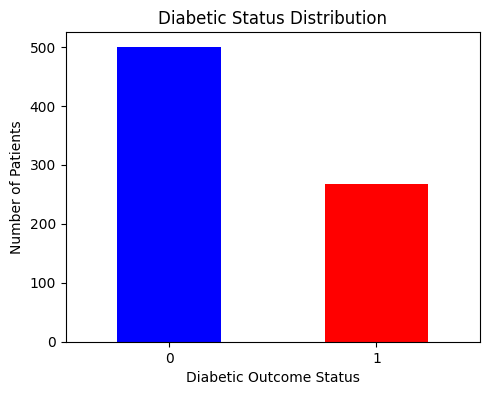

In [15]:
#Targeting class imbalance
target_col = "Outcome"

class_counts = df[target_col].value_counts()

plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Diabetic Status Distribution')
plt.xlabel('Diabetic Outcome Status')
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_2856/2444863149.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Outcome")
/tmp/ipykernel_2856/2444863149.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Outcome")
/tmp/ipykernel_2856/2444863149.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Outcome")
/tmp/ipykernel_2856/2444863149.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Outcome")
/tmp/ipykernel_2856/2444863149.p

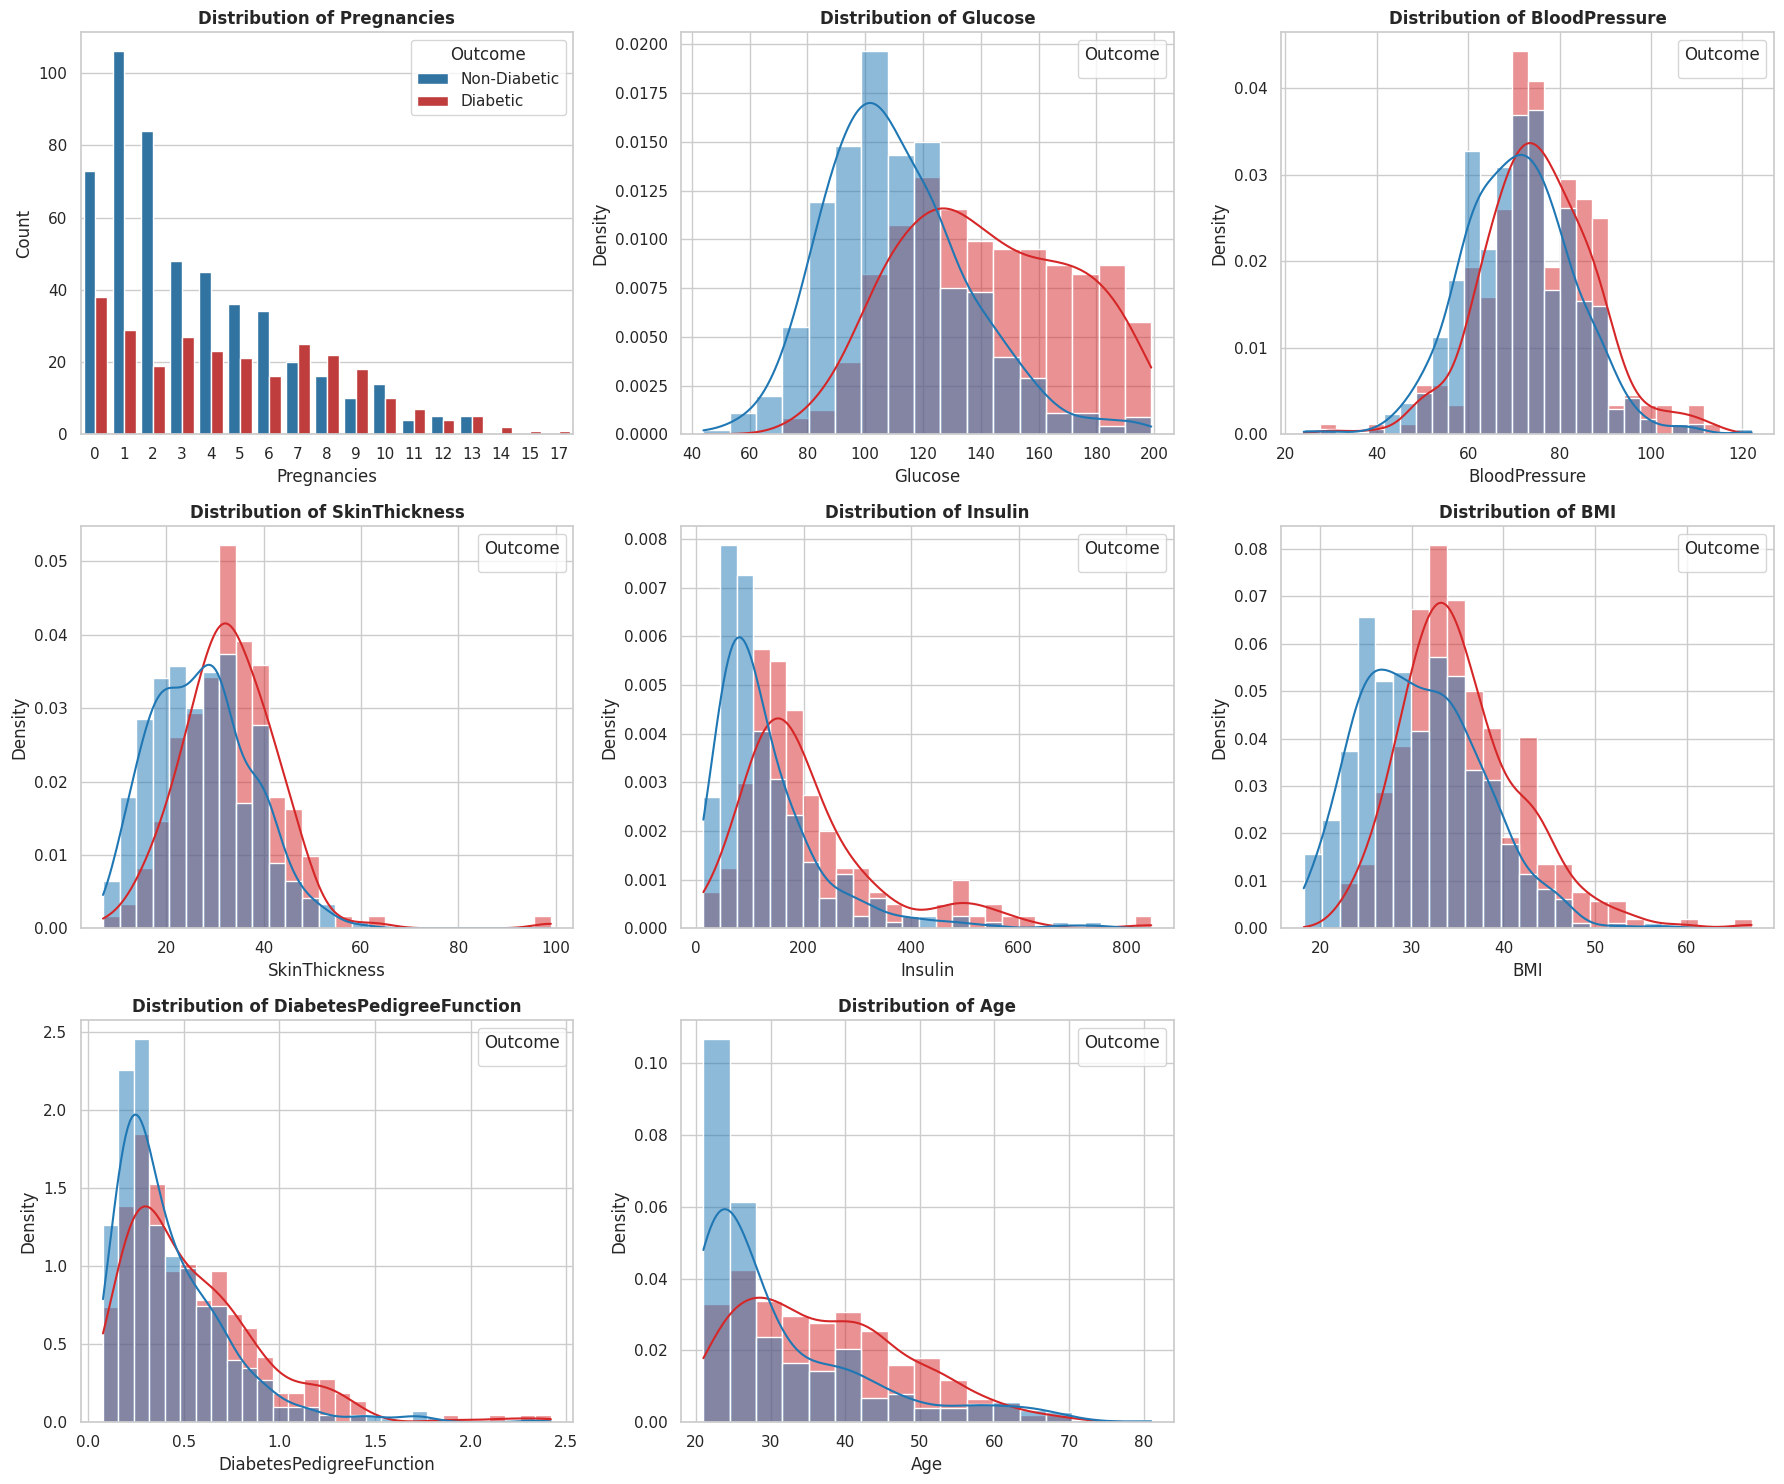

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="whitegrid")

df_plot = df.copy()
df_plot["Outcome_Label"] = df_plot["Outcome"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

palette = {
    "Non-Diabetic": "#1f77b4",
    "Diabetic": "#d62728"
}

cols = df_plot.columns.drop(["Outcome", "Outcome_Label"])

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    # SPECIAL HANDLING FOR DISCRETE PREGNANCIES
    if col == "Pregnancies":
        sns.countplot(
            data=df_plot,
            x=col,
            hue="Outcome_Label",
            hue_order=["Non-Diabetic", "Diabetic"],
            palette=palette,
            ax=axes[i]
        )
        axes[i].set_ylabel("Count")

    else:
        sns.histplot(
            data=df_plot,
            x=col,
            hue="Outcome_Label",
            hue_order=["Non-Diabetic", "Diabetic"],
            palette=palette,
            kde=True,
            stat="density",
            common_norm=False,
            multiple="layer",   # 🔥 prevents weird color blending
            alpha=0.5,
            edgecolor=None,
            ax=axes[i]
        )
        axes[i].set_ylabel("Density")

    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].legend(title="Outcome")

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Report of EDA

**Chart 1(Pregnancy):**  The Pregnancies variable exhibits a right-skewed distribution, with most patients reporting between zero and three pregnancies. While non-diabetic patients dominate lower pregnancy counts, the relative proportion of diabetic patients increases at higher counts. This pattern suggests a moderate association between pregnancy frequency and diabetes risk, potentially mediated by age and cumulative metabolic exposure. Although not a primary predictor, pregnancies likely contribute complementary information within multivariate models.

**Chart 2(Glucode):** Glucose concentration demonstrates the clearest separation between diabetic and non-diabetic patients, with a pronounced rightward shift in the diabetic group. This aligns with established clinical diagnostic criteria and confirms glucose as the dominant predictive feature.

**Chart 3(Blood Pressure):** blood pressure exhibits only moderate separation, reflecting its role as a secondary metabolic risk factor rather than a primary diagnostic indicator. While blood pressure contributes complementary information, glucose remains the most discriminative predictor in the dataset.

**Chart 4:** Skin thickness demonstrates substantial overlap between diabetic and non-diabetic groups, with only a slight elevation observed in diabetic patients. While biologically relevant as a proxy for adiposity, its discriminative power is limited relative to stronger predictors such as glucose and BMI. Skin thickness is therefore expected to contribute modestly within multivariate models.

**Chart 5:** Insulin levels exhibit extreme right skew and substantial variability, with several high outliers. Although diabetic patients tend to show elevated insulin values, significant overlap between groups reduces its standalone predictive strength. The high variability suggests that transformation or robust modeling techniques may be required to extract meaningful predictive signal.

**Chart 6:** BMI demonstrates clear separation between diabetic and non-diabetic individuals, with diabetic patients exhibiting consistently higher values. As obesity is a major risk factor for Type 2 diabetes, BMI is expected to serve as a strong predictive feature across both linear and nonlinear models.


**Chart 7:**The diabetes pedigree function shows moderate differentiation between groups, with diabetic patients exhibiting higher values on average. This supports the role of genetic predisposition in diabetes risk and suggests moderate predictive utility within multivariate models.

**Chart 8:** Age distribution reveals a noticeable rightward shift among diabetic patients, indicating increased prevalence in older individuals. As age is a well-documented risk factor for Type 2 diabetes, it is expected to contribute meaningfully to predictive performance.


**Final Observation:**

**Chart 7:**

### Correlation

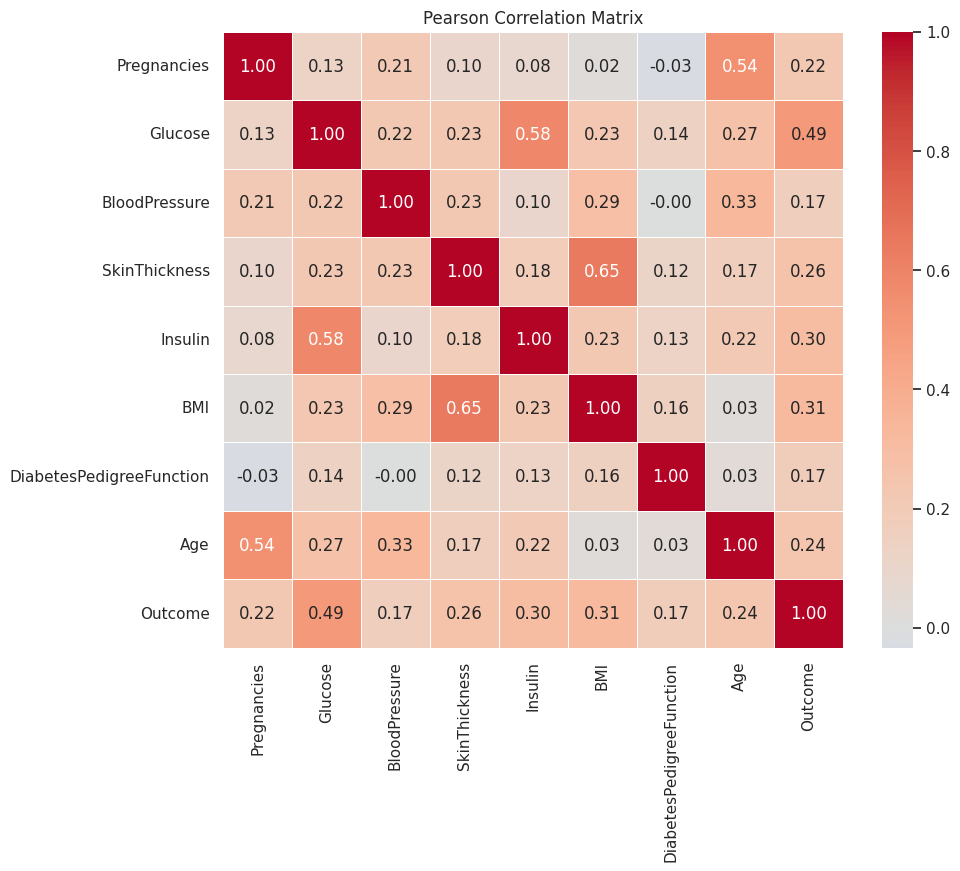

In [17]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(method ="pearson")

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt =".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.show()

####Pearson correlation analysis revealed that glucose concentration exhibits the strongest linear association with diabetes outcome (r = 0.49), followed by BMI (r = 0.31) and age (r = 0.24). Moderate correlations were observed between BMI and skin thickness (r = 0.54) and between pregnancies and age (r = 0.54), reflecting biologically related constructs. No severe multicollinearity was detected, supporting the suitability of these predictors for regression-based modeling.

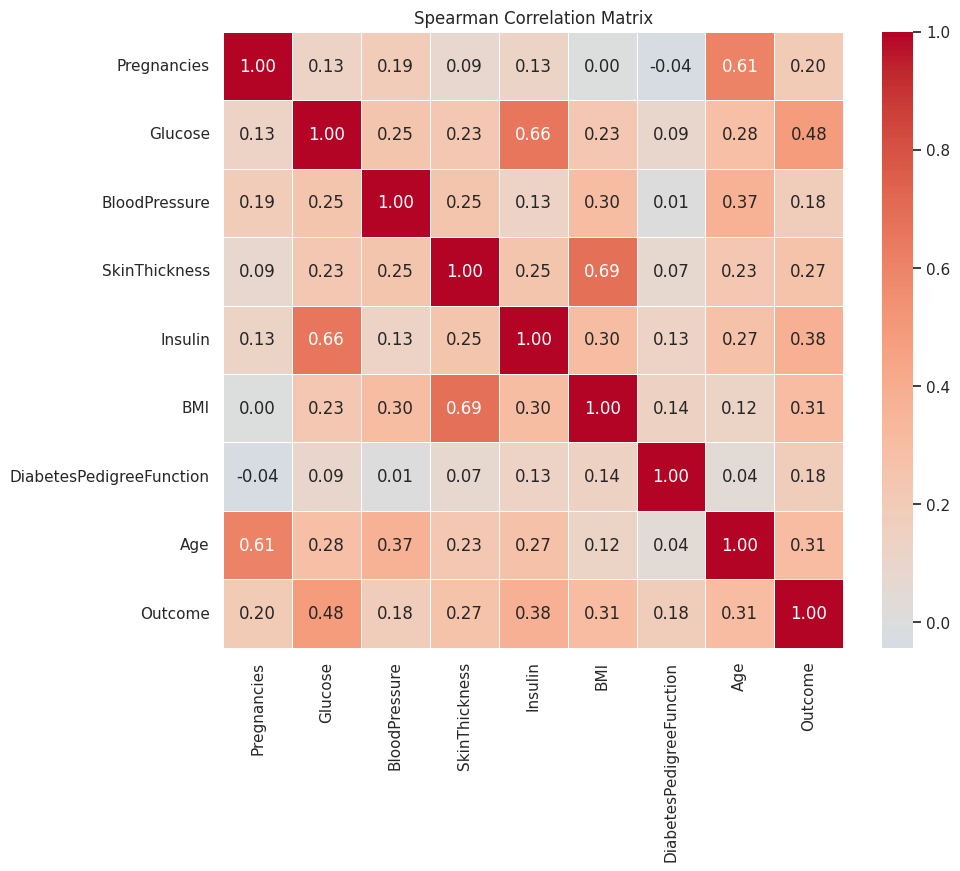

In [18]:
#spearman correlation
plt.figure(figsize=(10,8))

spearman_corr = df.corr(method="spearman")

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.show()

####Spearman correlation analysis revealed slightly stronger associations between age, insulin, and diabetes outcome compared to Pearson coefficients, indicating the presence of monotonic but potentially nonlinear relationships. This suggests that while linear models are appropriate, nonlinear models may capture additional predictive structure in the dataset.

/tmp/ipykernel_2856/1002715489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")


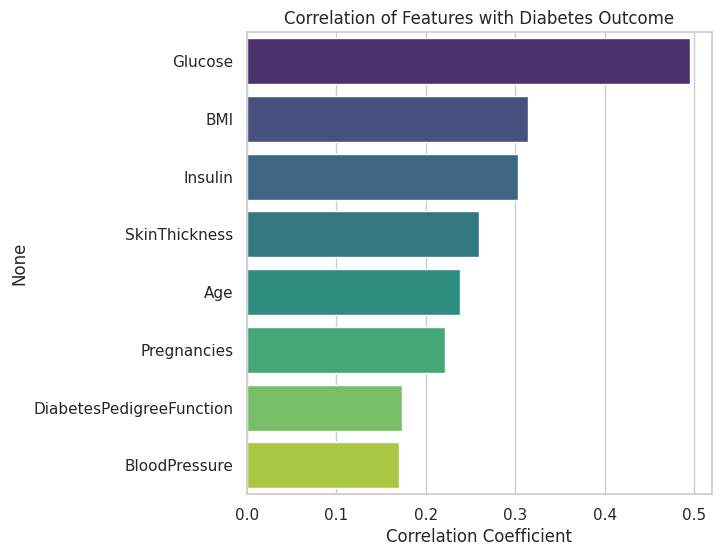

,Outcome
Glucose,0.494650
BMI,0.313680
Insulin,0.303454
SkinThickness,0.259491
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
BloodPressure,0.170589


In [19]:
target_corr = corr_matrix["Outcome"].drop("Outcome").sort_values(ascending=False)

plt.figure(figsize=(6,6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")
plt.title("Correlation of Features with Diabetes Outcome")
plt.xlabel("Correlation Coefficient")
plt.show()

target_corr

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = df.drop("Outcome", axis=1).dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(len(X_numeric.columns))
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
5,BMI,39.718222
2,BloodPressure,30.800794
1,Glucose,24.835772
7,Age,20.900840
3,SkinThickness,15.840516
4,Insulin,4.037994
0,Pregnancies,3.830630
6,DiabetesPedigreeFunction,3.450299


## Phase 2: Data Preprocessing & Feature Engineering

In [21]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [22]:
#defining pipeline for simple imputer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [23]:
#combine pipelines
X_train_processed = df_transformer.fit_transform(X_train)
X_test_processed = df_transformer.transform(X_test)

In [24]:
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)


Train shape: (614, 8)
Test shape: (154, 8)


In [25]:
# print(df.isnull().sum().sort_values(ascending= False))
print("Missing in X_train_processed:", np.isnan(X_train_processed).sum())
print("Missing in X_test_processed:", np.isnan(X_test_processed).sum())

Missing in X_train_processed: 0
Missing in X_test_processed: 0


In [26]:
#applying smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE class distribution:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE class distribution:
Outcome
0    400
1    400
Name: count, dtype: int64


## Phrase 3A: Machine Learning

In [27]:
#training with logistic regression model

from sklearn.linear_model import LogisticRegression

logReg_smote = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)

logReg_smote.fit(X_train_processed, y_train)

y_pred_lr = logReg_smote.predict(X_test_processed)
y_proba_lr = logReg_smote.predict_proba(X_test_processed)[:,1]

In [28]:
# Evaluate SMOTE model
print("Recall:", recall_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))

Recall: 0.7037037037037037
ROC-AUC: 0.8125925925925926
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [29]:
#training with Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_classifier.fit(X_train_processed, y_train)

#evaluate
y_pred_rf = rf_classifier.predict(X_test_processed)
y_proba_rf = rf_classifier.predict_proba(X_test_processed)[:, 1]

print("SVM (SMOTE) Recall:", recall_score(y_test, y_pred_rf))
print("SVM (SMOTE) ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


SVM (SMOTE) Recall: 0.6666666666666666
SVM (SMOTE) ROC-AUC: 0.8266666666666667
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       100
           1       0.63      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [30]:
#training with support Vector Machine (SVM)
from sklearn.svm import SVC

# svm = SVC(
#     probability=True,
#     class_weight='balanced',
#     random_state=42
# )

# svm.fit(X_train_processed, y_train)

svm_smote = SVC(
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_smote.fit(X_train_smote, y_train_smote)

#evaluate
y_pred_svm_sm = svm_smote.predict(X_test_processed)
y_proba_svm_sm = svm_smote.predict_proba(X_test_processed)[:, 1]

print("SVM (SMOTE) Recall:", recall_score(y_test, y_pred_svm_sm))
print("SVM (SMOTE) ROC-AUC:", roc_auc_score(y_test, y_proba_svm_sm))
print(classification_report(y_test, y_pred_svm_sm))

SVM (SMOTE) Recall: 0.6851851851851852
SVM (SMOTE) ROC-AUC: 0.8112037037037038
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       100
           1       0.60      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



In [31]:
# from xgboost import XGBClassifier
# from sklearn.metrics import recall_score, roc_auc_score, classification_report

# xgb_model = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=4,
#     eval_metric="logloss",
#     random_state=42,
#     verbosity=0,
#     use_label_encoder=False
# )

# # Train
# xgb_model.fit(X_train_processed, y_train)

# # Predict
# y_pred_xgb = xgb_model.predict(X_test_processed)
# y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# # Evaluate
# print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
# print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
# print(classification_report(y_test, y_pred_xgb))


from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score, classification_report

ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)

# Train
xgb_model.fit(X_train_processed, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_processed)
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluate
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Recall: 0.7037037037037037
XGBoost ROC-AUC: 0.8235185185185185
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       100
           1       0.63      0.70      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



In [32]:
# Logistic
recall_lr = recall_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Random Forest
recall_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# SVM
recall_svm = recall_score(y_test, y_pred_svm_sm)
auc_svm = roc_auc_score(y_test, y_proba_svm_sm)

# XGBoost
recall_xgb = recall_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

In [33]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "SVM (SMOTE)", "XGBoost"],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm_sm),
        recall_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm_sm),
        precision_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_svm_sm),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

comparison

,Model,Recall,Precision,ROC-AUC
0,Logistic,0.703704,0.603175,0.812593
1,Random Forest,0.666667,0.631579,0.826667
2,SVM (SMOTE),0.685185,0.596774,0.811204
3,XGBoost,0.703704,0.633333,0.823519


 ### Performing HyperParameter Tuning

In [34]:
#tuning logistic regression
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="recall",
    cv=5
)

grid_lr.fit(X_train_processed, y_train)

best_lr = grid_lr.best_estimator_

print("Best parameters:", grid_lr.best_params_)



y_pred_lr_tuned = best_lr.predict(X_test_processed)
y_proba_lr_tuned = best_lr.predict_proba(X_test_processed)[:, 1]

print("Tuned Logistic Recall:", recall_score(y_test, y_pred_lr_tuned))
print("Tuned Logistic Precision:", precision_score(y_test, y_pred_lr_tuned))
print("Tuned Logistic ROC-AUC:", roc_auc_score(y_test, y_proba_lr_tuned))
print(classification_report(y_test, y_pred_lr_tuned))


Best parameters: {'C': 1}
Tuned Logistic Recall: 0.5
Tuned Logistic Precision: 0.6
Tuned Logistic ROC-AUC: 0.812962962962963
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [35]:
#tuning SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10, 50],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid,
    scoring="recall",   # prioritize recall
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train_processed, y_train)

best_svm = grid_svm.best_estimator_

print("Best parameters:", grid_svm.best_params_)

y_pred_svm_tuned = best_svm.predict(X_test_processed)
y_proba_svm_tuned = best_svm.predict_proba(X_test_processed)[:,1]

print("Tuned SVM Recall:", recall_score(y_test, y_pred_svm_tuned))
print("Tuned SVM ROC-AUC:", roc_auc_score(y_test, y_proba_svm_tuned))

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Tuned SVM Recall: 0.5740740740740741
Tuned SVM ROC-AUC: 0.785


In [36]:
#tuning xgboost
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train_processed, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best parameters:", grid_xgb.best_params_)

y_pred_xgb_tuned = best_xgb.predict(X_test_processed)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test_processed)[:,1]

print("Tuned XGBoost Recall:", recall_score(y_test, y_pred_xgb_tuned))
print("Tuned XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_tuned))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Tuned XGBoost Recall: 0.7222222222222222
Tuned XGBoost ROC-AUC: 0.8225925925925925


In [40]:
#tuning xgboost with class_weight
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb = XGBClassifier(
    class_weight="balanced",
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train_processed, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best parameters:", grid_xgb.best_params_)

y_pred_xgb_tuned = best_xgb.predict(X_test_processed)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test_processed)[:,1]

print("Tuned XGBoost Recall:", recall_score(y_test, y_pred_xgb_tuned))
print("Tuned XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_tuned))

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Tuned XGBoost Recall: 0.6481481481481481
Tuned XGBoost ROC-AUC: 0.82


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:30:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Evaluation

In [38]:
from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    precision_score,
    classification_report,
    roc_curve,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X, y, name):

    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_proba)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Recall: {recall:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}\n")
    print("Classification Report:\n")
    print(classification_report(y, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

    # ------------------------
    # Confusion Matrix
    # ------------------------
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: Non-Diabetic", "Pred: Diabetic"],
        yticklabels=["Actual: Non-Diabetic", "Actual: Diabetic"]
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    # ------------------------
    # ROC Curve
    # ------------------------
    fpr, tpr, _ = roc_curve(y, y_proba)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return recall, precision, roc_auc


Tuned Logistic Regression
----------------------------------------
Recall: 0.500
Precision: 0.600
ROC-AUC: 0.813

Classification Report:

              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



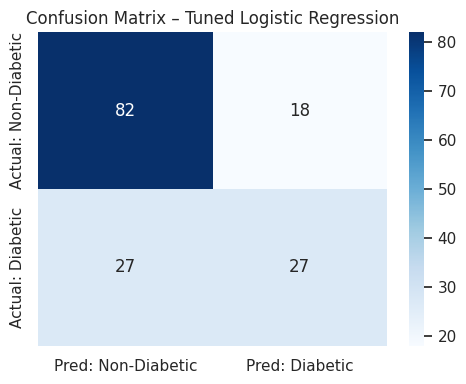

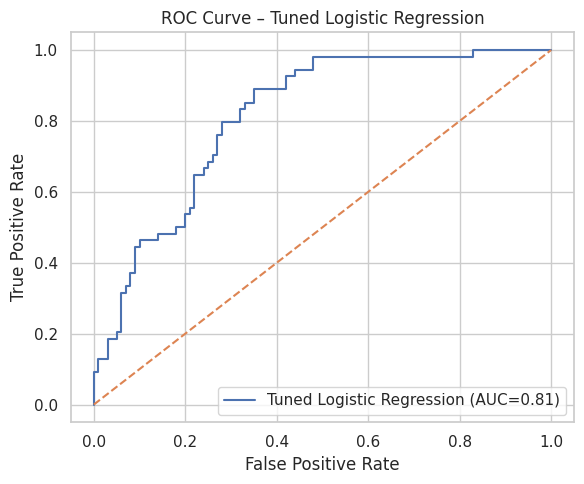

(0.5, 0.6, np.float64(0.812962962962963))

In [39]:
evaluate_model(best_lr, X_test_processed, y_test, "Tuned Logistic Regression")